## 导入包

In [1]:
import os
import datetime
import argparse
import time
import numpy as np
import torch as th
import torch.distributed as dist
import matplotlib.pyplot as plt
import gc
from pathlib import Path

from improved_diffusion import dist_util, logger
from improved_diffusion.dataset import get_dataloader, yield_dataloader, show_dataloader, show_samples
from improved_diffusion.resample import create_named_schedule_sampler
from improved_diffusion.script_util import (
    model_and_diffusion_defaults,
    create_model_and_diffusion,
    args_to_dict,
    add_dict_to_argparser,
    sample_filter,
)
from improved_diffusion.losses import compute_F1_score
from improved_diffusion.train_util import TrainLoop

## 参数设置

In [2]:
def create_argparser():
    defaults = model_and_diffusion_defaults()
    
    my_config = dict(
        root_folder_data_train = Path('../datasets/PPD/train'),
        folder_Mo_train ='MAP_with_start_end',
        folder_P_train ='PATH_20PIXEL',
        num_images_train = 12000,
        root_folder_data_sample = Path('../datasets/PPD/test/UNSEEN'),
        folder_Mo_sample ='MAP_with_start_end',
        folder_P_sample ='PATH_20PIXEL',
        num_images_sample = 1200,
        batch_size=8,
        image_size=64,
        gradient_accumulation_steps=100,
        

        use_CFM = True,
        biased_initialization = 0,   # 是否使用 偏置初始化-范式P2
        use_MFF_MAC = False,             # 是否使用 MFF_MAC


        schedule_sampler="uniform",     
        lr=1e-4,                        # Adamw的学习率
        weight_decay=0.0,               # Adamw的权重衰减
        lr_anneal_steps=1000,
        microbatch=-1,                  # -1 disables microbatches
        ema_rate="0.99",               # comma-separated list of EMA values
        resume_checkpoint="",
        use_fp16=False,
        fp16_scale_growth=1e-3,
    )
    
    defaults.update(my_config)
    parser = argparse.ArgumentParser()
    add_dict_to_argparser(parser, defaults)
    
    return parser

## 定义测试矩阵

In [3]:
# "use_MFF_MAC": False
# test_matrix = [
#     {"use_CFM": False, "biased_initialization": 0   , "use_MFF_MAC": False},
#     {"use_CFM": False, "biased_initialization": 1e-3, "use_MFF_MAC": False},

#     {"use_CFM": False, "biased_initialization": 0   , "use_MFF_MAC": False},
#     {"use_CFM": False, "biased_initialization": 1e-3, "use_MFF_MAC": False},


#     {"use_CFM": True , "biased_initialization": 1   , "use_MFF_MAC": False},
#     {"use_CFM": True , "biased_initialization": 0   , "use_MFF_MAC": False},
#     {"use_CFM": True , "biased_initialization": 1e-3, "use_MFF_MAC": False},

#     {"use_CFM": True , "biased_initialization": 1   , "use_MFF_MAC": False},
#     {"use_CFM": True , "biased_initialization": 0   , "use_MFF_MAC": False},
#     {"use_CFM": True , "biased_initialization": 1e-3, "use_MFF_MAC": False},
# ]

# # "use_MFF_MAC": True
# test_matrix = [
#     {"use_CFM": False, "biased_initialization": 0   , "use_MFF_MAC": True},
#     {"use_CFM": False, "biased_initialization": 1e-3, "use_MFF_MAC": True},

#     {"use_CFM": False, "biased_initialization": 0   , "use_MFF_MAC": True},
#     {"use_CFM": False, "biased_initialization": 1e-3, "use_MFF_MAC": True},


#     {"use_CFM": True , "biased_initialization": 1   , "use_MFF_MAC": True},
#     {"use_CFM": True , "biased_initialization": 0   , "use_MFF_MAC": True},
#     {"use_CFM": True , "biased_initialization": 1e-3, "use_MFF_MAC": True},

#     {"use_CFM": True , "biased_initialization": 1   , "use_MFF_MAC": True},
#     {"use_CFM": True , "biased_initialization": 0   , "use_MFF_MAC": True},
#     {"use_CFM": True , "biased_initialization": 1e-3, "use_MFF_MAC": True},
# ]

test_matrix = [
    # {"use_CFM": False, "biased_initialization": 0   , "use_MFF_MAC": False},
    # {"use_CFM": False, "biased_initialization": 1e-3, "use_MFF_MAC": False},

    # {"use_CFM": False, "biased_initialization": 0   , "use_MFF_MAC": True },
    # {"use_CFM": False, "biased_initialization": 1e-3, "use_MFF_MAC": True },



    {"use_CFM": True , "biased_initialization": 0   , "use_MFF_MAC": False},

    # {"use_CFM": True , "biased_initialization": 0   , "use_MFF_MAC": True},
]

## 循环测试

Starting Experiment: use_CFM=True, biased_initialization=0, use_MFF_MAC=False
Logging to /home/pengs/DiffRP_IDDPM/my_model_checkpoints/Ablation exp-2026-05-03-12-58-18-CFM_True-P2_0-use_MFF_MAC-False-PATH_20PIXEL-img64-batch_8-epochs1000
diffusion: CFM_without_MFF_MCA
diffusion: CFM_without_MFF_MCA
成功加载 12000 对图片:
 - M_o的尺寸为 torch.Size([1, 64, 64]), 值域为: [-1.00, 1.00]
 - M_r的尺寸为 torch.Size([3, 64, 64]), 值域为: [-1.00, 1.00]
 - P的尺寸为   torch.Size([1, 64, 64]), 值域为: [-1.00, 1.00]
成功加载 1200 对图片:
 - M_o的尺寸为 torch.Size([1, 64, 64]), 值域为: [-1.00, 1.00]
 - M_r的尺寸为 torch.Size([3, 64, 64]), 值域为: [-1.00, 1.00]
 - P的尺寸为   torch.Size([1, 64, 64]), 值域为: [-1.00, 1.00]
training...
-----------------------------------
| CollisionRate        | 2.2e-05  |
| CollisionRate(EMA)   | 0        |
| F1                   | 0.335    |
| F1(EMA)              | 0.253    |
| grad_norm            | 4.85     |
| loss                 | 0.838    |
| loss_q0              | 0.897    |
| loss_q1              | 0.79     |
| l

/home/pengs/DiffRP_IDDPM/improved_diffusion/dist_util.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return th.load(io.BytesIO(data), **kwargs)


sampling...
F1 = 0.6068 | Batch Time: 0.83s | Speed: 0.0130s/sample
--------------------------------------
| batch_inference_seconds | 0.831    |
| F1                      | 0.607    |
| sec_per_sample          | 0.013    |
--------------------------------------
Final Inference Total Time (s): 0.8348684310913086
Average Speed: 0.0130s/sample
sampling complete


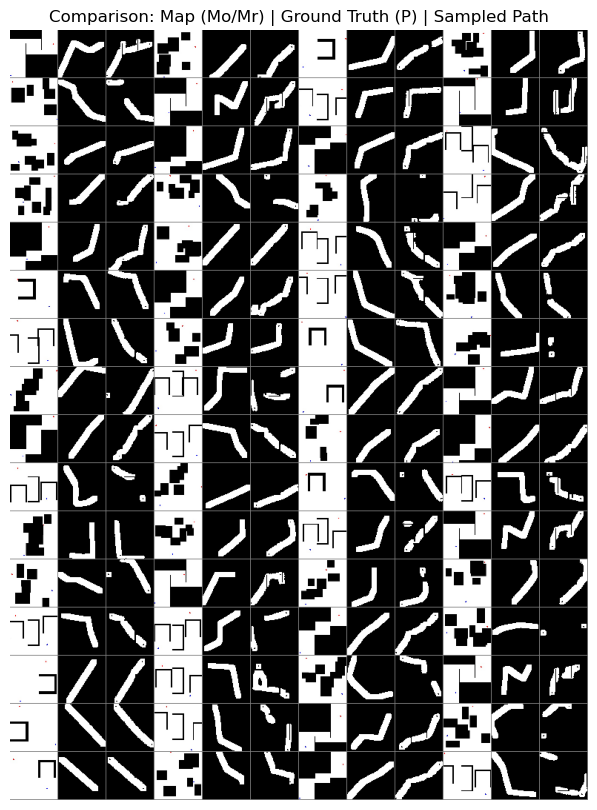

('805.jpg', '1124.jpg', '66.jpg', '1145.jpg', '1029.jpg', '653.jpg', '411.jpg', '733.jpg', '1183.jpg', '824.jpg', '721.jpg', '389.jpg', '1119.jpg', '973.jpg', '933.jpg', '585.jpg', '851.jpg', '1128.jpg', '500.jpg', '877.jpg', '133.jpg', '793.jpg', '321.jpg', '924.jpg', '501.jpg', '953.jpg', '44.jpg', '1051.jpg', '1135.jpg', '556.jpg', '104.jpg', '867.jpg', '622.jpg', '526.jpg', '1186.jpg', '820.jpg', '300.jpg', '1142.jpg', '165.jpg', '485.jpg', '1060.jpg', '1081.jpg', '373.jpg', '683.jpg', '1071.jpg', '847.jpg', '1098.jpg', '969.jpg', '386.jpg', '594.jpg', '885.jpg', '1103.jpg', '235.jpg', '443.jpg', '1011.jpg', '620.jpg', '19.jpg', '582.jpg', '638.jpg', '909.jpg', '273.jpg', '1108.jpg', '784.jpg', '562.jpg')


In [4]:
summary_results = {}

for config in test_matrix:
    print("="*50)
    config_str = ", ".join([f"{k}={v}" for k, v in config.items()])
    print(f"Starting Experiment: {config_str}")
    print("="*50)   

    # 1. 获取默认参数并更新当前实验配置
    parser = create_argparser()
    args = parser.parse_args([])
    args.log_interval=args.lr_anneal_steps/10
    args.save_interval=args.lr_anneal_steps/10
    
    # 更新当前循环的特定参数
    args.use_CFM = config['use_CFM']
    args.use_MFF_MAC = config['use_MFF_MAC']
    args.biased_initialization = config['biased_initialization']

    # 2. 动态生成唯一的日志目录
    subdir = f'Ablation exp-' + datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S") + f'-CFM_{args.use_CFM}-P2_{args.biased_initialization}-use_MFF_MAC-{args.use_MFF_MAC}-{args.folder_P_train}-img{args.image_size}-batch_{args.batch_size}-epochs{args.lr_anneal_steps}'
    log_dir = os.path.join(os.path.expanduser("~/DiffRP_IDDPM/my_model_checkpoints"), subdir)
    
    # 强制更新环境变量（确保 logger 使用新的路径）
    os.environ["OPENAI_LOGDIR"] = log_dir
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)
    
    # 3. 重新配置 logger
    dist_util.setup_dist()  # 设置分布式训练环境，确保在多GPU或多节点环境下正确地初始化通信和资源分配
    logger.configure(dir=log_dir) 
    
    # 4. 创建模型和扩散过程
    model, diffusion = create_model_and_diffusion(**args_to_dict(args, model_and_diffusion_defaults().keys()))
    model.to(dist_util.dev())
    
    # 创建专门用于推理采样的扩散对象（固定为 ddim 或其他步数）
    args.clip_denoised = True
    args.use_ddim = True
    args.timestep_respacing = "ddim20"
    _, sample_diffusion = create_model_and_diffusion(
        **args_to_dict(args, model_and_diffusion_defaults().keys())
    )

    # 5. 加载数据
    data = yield_dataloader(get_dataloader(
        root_folder_data=args.root_folder_data_train,
        folder_Mo=args.folder_Mo_train,
        folder_P=args.folder_P_train,
        num_images=args.num_images_train,
        batch_size=args.batch_size,
        image_size=args.image_size,
    ))
    
    # 用于验证的固定样本
    dataloader_sample = get_dataloader(
        root_folder_data=args.root_folder_data_sample,
        folder_Mo=args.folder_Mo_sample,
        folder_P=args.folder_P_sample,
        num_images=args.num_images_sample,
        batch_size=64,                  # 取64个样本进行训练过程中的测试
        image_size=args.image_size,
        shuffle=True,
    )
    sample_Mo, sample_Mr, sample_P, _, _ = next(iter(dataloader_sample))


    # ===================================== 训练 =====================================
    logger.log("training...")
    training_loop = TrainLoop(
        model=model,
        diffusion=diffusion,
        sample_diffusion=sample_diffusion,
        sample_Mo=sample_Mo,
        sample_Mr=sample_Mr,
        sample_P=sample_P,
        data=data,
        batch_size=args.batch_size,
        microbatch=args.microbatch,
        lr=args.lr,
        ema_rate=args.ema_rate,
        log_interval=args.log_interval,
        save_interval=args.save_interval,
        resume_checkpoint=args.resume_checkpoint,
        use_fp16=args.use_fp16,
        fp16_scale_growth=args.fp16_scale_growth,
        schedule_sampler=create_named_schedule_sampler(args.schedule_sampler, diffusion),
        weight_decay=args.weight_decay,
        lr_anneal_steps=args.lr_anneal_steps,
        gradient_accumulation_steps=args.gradient_accumulation_steps,
    ).run_loop()
    logger.log("training complete")


    # ===================================== 推理 =====================================
    args.clip_denoised = True
    args.num_samples = 64
    args.use_ddim = True
    args.timestep_respacing = "ddim20"

    logger.log("loading trained state dict...")
    model_path=os.path.join(os.environ["OPENAI_LOGDIR"], 'model_ema.pt' )
    
    logger.log(f"creating model_sample and diffusion_sample (use MFF/MCA:{args.use_MFF_MAC})...")
    model, diffusion = create_model_and_diffusion(
        **args_to_dict(args, model_and_diffusion_defaults().keys())
    )

    model.load_state_dict(
        dist_util.load_state_dict(model_path, map_location="cpu")
    )
    model.to(dist_util.dev())
    model.eval()

    logger.log("creating data loader_sample...")
    dataloader = get_dataloader(args.root_folder_data_sample, args.folder_Mo_sample, args.folder_P_sample, args.num_images_sample, args.num_samples, args.image_size, shuffle=True)
    M_o, M_r, P, _, img_name = next(iter(dataloader))

    logger.log("sampling...")
    inference_start_time = time.time()
    all_images = []
    all_labels = []
    while len(all_images) * args.num_samples < args.num_samples:
        model_kwargs = {}

        batch_start = time.time()
        sample = diffusion.sample_loop(
            model,
            M_o,
            M_r,
            M_o.shape,
            clip_denoised=args.clip_denoised,
            model_kwargs=model_kwargs,
        )
        batch_time = time.time() - batch_start

        sec_per_sample = batch_time / args.num_samples
        sample_filtered = sample_filter(sample, threshold_255=150)
        f1 = compute_F1_score(P.to(dist_util.dev()), sample_filtered.to(dist_util.dev()), thresh_hold=0)

        if dist.get_rank() == 0:
            print(f'F1 = {f1:.4f} | Batch Time: {batch_time:.2f}s | Speed: {sec_per_sample:.4f}s/sample')
            logger.logkv("F1", f1)
            logger.logkv("batch_inference_seconds", batch_time)
            logger.logkv("sec_per_sample", sec_per_sample)
            logger.dumpkvs() # 立即将当前指标写入日志文件

        sample_filtered = ((sample_filtered + 1) * 127.5).clamp(0, 255).to(th.uint8)
        sample_filtered = sample_filtered.permute(0, 2, 3, 1)
        sample_filtered = sample_filtered.contiguous()

        gathered_samples_filtered = [th.zeros_like(sample_filtered) for _ in range(dist.get_world_size())]
        dist.all_gather(gathered_samples_filtered, sample_filtered)  # gather not supported with NCCL
        all_images.extend([sample_filtered.cpu().numpy() for sample_filtered in gathered_samples_filtered])

    total_inference_time = time.time() - inference_start_time
    if dist.get_rank() == 0:
        logger.log(f"Final Inference Total Time (s): {total_inference_time}")
        logger.log(f"Average Speed: {total_inference_time / (len(all_images) * args.num_samples):.4f}s/sample")

        summary_results[config_str] = {
            "batch_inference_seconds": batch_time,
            "F1": f1,
            "sec_per_sample": sec_per_sample
        }

    arr = np.concatenate(all_images, axis=0)
    arr = arr[: args.num_samples]
    if args.class_cond:
        label_arr = np.concatenate(all_labels, axis=0)
        label_arr = label_arr[: args.num_samples]
    if dist.get_rank() == 0:
        shape_str = "x".join([str(x) for x in arr.shape])
        out_path = os.path.join(logger.get_dir(), f"samples_{shape_str}.npz")
        # logger.log(f"saving to {out_path}")
        if args.class_cond:
            np.savez(out_path, arr, label_arr)
        else:
            np.savez(out_path, arr)

    dist.barrier()
    logger.log("sampling complete")

    show_samples(args, arr, M_r, P, img_name)


    # ===================================== 清理显存 =====================================
    # 1. 删除包含大量显存占用（模型参数、梯度、优化器状态）的对象
    del model
    del diffusion
    del sample_diffusion
    del training_loop
    del data
    del dataloader_sample, dataloader
    
    # 2. 强制进行垃圾回收
    gc.collect()
    
    # 3. 清空 PyTorch 的显存缓存池
    if th.cuda.is_available():
        th.cuda.empty_cache()

In [5]:
if dist.get_rank() == 0:
    print("\n" + "="*50)
    print("All Experiments Summary Report")
    print("="*50 + "\n")
    
    for cfg_str, metrics in summary_results.items():
        print(cfg_str)
        print("-" * 38)
        print(f"| {'batch_inference_seconds':<23} | {metrics['batch_inference_seconds']:<8.2f} |")
        print(f"| {'F1':<23} | {metrics['F1']:<8.3f} |")
        print(f"| {'sec_per_sample':<23} | {metrics['sec_per_sample']:<8.3f} |")
        print("-" * 38)
        print()


All Experiments Summary Report

use_CFM=True, biased_initialization=0, use_MFF_MAC=False
--------------------------------------
| batch_inference_seconds | 0.83     |
| F1                      | 0.607    |
| sec_per_sample          | 0.013    |
--------------------------------------

